- introduce magcut into query using most recent mag obs (testable variable)
- introduce limit into S_2 to only include recent alerts (testable variable)
- do loops so i can include all bands, not just r band

consider: issues w science flux if an object is extended

In [251]:
from antares_devkit.models import BaseFilter
from antares_devkit.models import DevKitLocus
from antares_client import search
import numpy as np
import matplotlib.pyplot as plt
from astropy.time import Time
import pandas as pd
import math

t_now = Time.now().mjd

In [160]:
t_now

np.float64(61192.720234695465)

In [3]:
mag_max = 22

q_lsst_magcut = {
    "query": {
        "bool": {
            "filter": [
                { "range": { "properties.newest_alert_observation_time": { "gte": t_now-50} } },
                { "range": { "properties.newest_alert_magnitude": { "lte": mag_max} } },
                { "exists": { "field": "properties.survey.lsst" } },
             ]
        }
    }
}


In [5]:
q_lsst = list(search.search(q_lsst_magcut))

In [135]:
q_lsst_1 = list(search.search(q_lsst_magcut))

In [19]:
oids = {}
i = 0
for ant_id in search.search(q_lsst_magcut):
    oid_dev = ant_id.to_devkit()
    oid_locus = DevKitLocus.model_validate(oid_dev)
    lsst_alerts = []
    
    for alert in oid_locus.alerts:
        if 'lsst_diaSource_scienceFlux' in alert.properties:
            lsst_alerts.append(alert)
    i += 1 
    if len(lsst_alerts) > 2:
        oids[oid_dev['id']] = lsst_alerts
        print(i, oid_dev['id'], len(oids[oid_dev['id']]))

    if len(oids) > 10000:
        break

36 ANT2020b6idk 3
72 ANT2020bwpqc 3
77 ANT2020akjts 3
81 ANT2020amvnw 4
95 ANT2026n1edlvfi46ko 3
97 ANT2020akhwk 3
98 ANT2020bk53s 3
106 ANT2020akml6 3
142 ANT2020bvc3k 3
181 ANT2020b33ui 3
211 ANT2020amnm2 3
213 ANT2018jx7a 300
215 ANT2020aj2om 235
217 ANT20192jrs2 513
218 ANT2021dxng2 105
219 ANT2023weuauwjev6fp 431
220 ANT2020ajvae 169
221 ANT2020alno6 54
222 ANT2020bdma4 263
223 ANT20193wfwm 562
224 ANT2020ajwra 245
225 ANT2020alwb6 220
226 ANT2020ajvtc 4
227 ANT2020afmebza 48
228 ANT2020ajw66 100
229 ANT2020ajw2i 350
230 ANT2020alvpw 218
231 ANT2020ajz7c 4
232 ANT2021ibszs 3
234 ANT2021cwiqm 520
235 ANT2020ajyck 358
239 ANT2026wj3tenqt6czr 190
240 ANT2020ebyjs 112
241 ANT2026unysy95csl2h 338
245 ANT2026ak9d2a5d22eg 212
247 ANT2026vhx58mmsgmvv 18
250 ANT2026ddm914zxymi4 26
252 ANT20192csso 62
254 ANT2026a2uvfvo5xmzh 248
257 ANT2026wffksjpicsx3 3
261 ANT20193vfsk 3
262 ANT2026kz9eww18y2er 162
267 ANT2026kj522l1uye2t 306
269 ANT2024dsttx2qz7b2l 559
271 ANT2026aw1spk40csvo 366
273 ANT

ConnectionError: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))

In [137]:
oids_1 = {}
i = 0
for ant_id in search.search(q_lsst_magcut):
    oid_dev = ant_id.to_devkit()
    oid_locus = DevKitLocus.model_validate(oid_dev)
    lsst_alerts = []
    
    for alert in oid_locus.alerts:
        if 'lsst_diaSource_scienceFlux' in alert.properties:
            lsst_alerts.append(alert)
    i += 1 
    if len(lsst_alerts) > 2:
        oids_1[oid_dev['id']] = lsst_alerts
        print(i, oid_dev['id'], len(oids_1[oid_dev['id']]))

    if len(oids_1) > 10000:
        break

4 ANT2020bk5jw 3
17 ANT2020bk53s 3
18 ANT2020akhwk 3
46 ANT2020amowa 3
62 ANT2020a4pzu 3
105 ANT2020amvnw 4
126 ANT2020blzvm 3
131 ANT2020amwbw 3
170 ANT2020dxeoy 3
178 ANT2020bgmzw 3
179 ANT2020biimu 4
187 ANT2020biimu 4
190 ANT2020amo6a 3
245 ANT2020bqguk 3
249 ANT2020bimk2 3
255 ANT2020bgmxw 5
281 ANT2020bar2w 3
307 ANT2020a4hqc 3
348 ANT2026n1edlvfi46ko 3
351 ANT2020akjaa 3
395 ANT2020a4ves 3
403 ANT2020ake62 3
410 ANT2020akfdk 3
414 ANT2020bfpz4 3
426 ANT2020am222 3
428 ANT2020b33ui 3
430 ANT2020bstmk 3
436 ANT2023ltwi9jw28cdv 3
438 ANT2020biztc 3
444 ANT2020amqfk 3
470 ANT2020amo6s 4
483 ANT2020bja52 4
489 ANT2020amx6w 3
504 ANT2020amr3u 4
509 ANT2020amvci 3
516 ANT2020bjdyk 5
517 ANT2020amsfe 4
518 ANT2020amt6k 4
519 ANT2020amvci 3
530 ANT2020amy7g 3
540 ANT2020am4am 3
586 ANT2021dxng2 105
587 ANT2020alm3s 5
588 ANT2023weuauwjev6fp 431
589 ANT2021dxca2 66
590 ANT2020ajvae 169
591 ANT2020ajzl6 578
592 ANT2020alno6 54
593 ANT20193wfwm 562
594 ANT2020ajwra 245
595 ANT2020alwb6 220


In [138]:
len(oids_1)

440

In [52]:
oid_mags = {}
for key, alerts in oids.items():
    # oid_mags[key] = {'mag': [], 'temp_mag': [], 'dif_mag': [], 'variance': 0, 'hyper_v': 0, 'band': [], 'snr' : []}

    oid_mags[key] = {'g': 0, 'r': 0, 'i': 0, 'z': 0, 'u': 0, 'y': 0}
   
    for alert in alerts:
        obs_date = float(alert.properties['lsst_diaSource_midpointMjdTai'])
        here_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_scienceFlux']) + 31.4)
        here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)
        here_dif_mag = float(here_temp_mag - here_mag)
        
        band_here = alert.properties['ant_passband']

        if oid_mags[key][band_here] == 0:
            oid_mags[key][band_here] = {'mjd': [], 'mag': [], 'temp_mag': [], 'dif_mag': [], 'snr' : [], 'variance': 0, 'hyper_v': 0}
      
        oid_mags[key][band_here]['mjd'].append(obs_date)
        oid_mags[key][band_here]['mag'].append(here_mag)
        oid_mags[key][band_here]['temp_mag'].append(here_temp_mag)
        oid_mags[key][band_here]['dif_mag'].append(here_dif_mag)
        oid_mags[key][band_here]['snr'].append(alert.properties['lsst_diaSource_snr'])

    for band in oid_mags[key]:
        if oid_mags[key][band] == 0:
            continue
            
        latest_mjd = oid_mags[key][band]['mjd'][-1]
        alert_num_20d = 0 #number of alerts within 20 days of latest_mjd 
        for mjd in oid_mags[key][band]['mjd']:
            if mjd >= float(latest_mjd) - 20:
                alert_num_20d += 1

        if alert_num_20d > 2: #if more +3 alerts w/in 20 days of latest_mjd, then we look at the variance + hyper_v (only including alerts w/in time frame)
            here_var = float(np.var(oid_mags[key][band]['mag'][-alert_num_20d-1:]))
            here_difs = float(np.median(oid_mags[key][band]['dif_mag'][-alert_num_20d-1:]))
            here_V = float(np.sqrt(here_difs**2 + (4*here_var)**2))
        
            oid_mags[key][band]['variance'] = here_var
            oid_mags[key][band]['hyper_v'] = here_V

            if here_var >= 0.1:
                print(f"{key}: hypervariance V: {oid_mags[key][band]['hyper_v']}, variance: {oid_mags[key][band]['variance']}, latest observation: {latest_mjd}\nmags: {oid_mags[key][band]['mag'][-alert_num_20d-1:]}\ntemplate mags: {oid_mags[key][band]['temp_mag'][-alert_num_20d-1:]}\nmjds: {oid_mags[key][band]['mjd'][-alert_num_20d-1:]}\n")

        

ANT2020ajwra: hypervariance V: 0.8733501788285769, variance: 0.181161006499758, latest observation: 61098.22936006922
mags: [16.754369942453565, 16.833530819604537, 16.75424035122314, 16.76414805905497, 16.72630886267265, 16.729175852030966, 16.732253700770233, 16.717323664125768, 16.859820249003867, 16.77972059744183, 16.751714907830046, 16.850810377736323, 16.777715982407592, 16.758661196591458, 15.885704515346072, 15.896175117378121, 15.921545311568341, 15.927325808030965, 15.9286145431683, 15.918697925790648, 15.918736084637812, 15.946526914882304, 15.951151310182137, 15.95057653364606, 16.081609228931903, 16.073963027430217, 16.08830364142615, 16.0830790663562, 16.070295100633537, 16.094221878245584, 16.076163360676578, 16.860120746425785, 16.723236647013447, 16.722619025860197, 16.696911242652405, 16.715064127099982, 16.68954076587643, 16.69344997591245, 16.012198257442055, 15.971235007713398, 15.971323249297846, 15.942068195675347, 15.959241961463855, 15.916208043441289, 15.8985

/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_14463/3763676145.py:9: RuntimeWarning: invalid value encountered in log10
  here_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_scienceFlux']) + 31.4)
/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_14463/3763676145.py:10: RuntimeWarning: invalid value encountered in log10
  here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)


In [159]:
#inputs: dict of DevKitAlerts by antares_id, num of days from latest mjd to check, threshold for variance
#outputs: dict of mjd, mag, temp_mag, dif_mag, snr, varianace, and hyper_v by antares_id
# only includes oids that pass the variance limit in at least 1 band
def check_var(oids, day_lim, var_thresh):
    oid_mags = {}

    for key, alerts in oids.items():
        temp_oid = {'u': 0, 'g': 0, 'r': 0, 'i': 0, 'z': 0, 'y': 0}
        oid_mags[key] = temp_oid
        for alert in alerts: #
            tot_flux = float(alert.properties['lsst_diaSource_scienceFlux'] + alert.properties['lsst_diaSource_templateFlux'])
            
            obs_date = float(alert.properties['lsst_diaSource_midpointMjdTai'])
            here_mag = float(-2.5*np.log10(tot_flux) + 31.4)
            here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)
            here_dif_mag = float(here_temp_mag - here_mag)
        
            band_here = alert.properties['ant_passband']

            if np.isnan(here_mag) == True:
                print(alert.properties['lsst_diaSource_scienceFlux'])
            
            if temp_oid[band_here] == 0:
                temp_oid[band_here] = {'mjd': [], 'mag': [], 'temp_mag': [], 'dif_mag': [], 'snr' : [], 'variance': 0, 'hyper_v': 0}
                # temp_oid[band_here] = [pd.Dataframe(columns=['mjd', 'mag', 'temp_mag','dif_mag', 'snr']), 'variance': 0, 'hyper_v': 0}
      
            temp_oid[band_here]['mjd'].append(obs_date)
            temp_oid[band_here]['mag'].append(here_mag)
            temp_oid[band_here]['temp_mag'].append(here_temp_mag)
            temp_oid[band_here]['dif_mag'].append(here_dif_mag)
            temp_oid[band_here]['snr'].append(alert.properties['lsst_diaSource_snr'])
        
        latest_alert = oids[key][-1].properties
        latest_mjd = latest_alert['lsst_diaSource_midpointMjdTai'] #mjd from most recent alert
        
        obs_lim = 0
        var_lim = 0
        
        for band in temp_oid:
            if temp_oid[band] == 0: #are there any obs in that band?
                obs_lim += 1
                continue
            
            recent_obs = 0 #number of alerts within day_lim of latest_mjd 
            for mjd in temp_oid[band]['mjd']:
                if mjd >= float(latest_mjd) - day_lim:
                    recent_obs += 1

            if recent_obs > 2: #if +3 alerts w/in day_lim of latest_mjd, then we look at the variance + hyper_v (only including alerts w/in time frame)
                here_var = float(np.var(temp_oid[band]['mag'][-recent_obs-1:]))
                here_difs = float(np.median(temp_oid[band]['dif_mag'][-recent_obs-1:]))
                here_V = float(np.sqrt(here_difs**2 + (4*here_var)**2))
                temp_oid[band]['variance'] = here_var
                temp_oid[band]['hyper_v'] = here_V

                if here_var <= var_thresh:
                    var_lim += 1
            else:
                obs_lim += 1
        if obs_lim + var_lim == 6:
            oid_mags.pop(key, None)
        else:
            oid_mags[key][band] = temp_oid[band]
                # print(f"{key}: hypervariance V: {oid_mags[key][band]['hyper_v']}, variance: {oid_mags[key][band]['variance']}, latest observation: {latest_mjd}\nmags: {oid_mags[key][band]['mag'][-recent_obs-1:]}\ntemplate mags: {oid_mags[key][band]['temp_mag'][-recent_obs-1:]}\nmjds: {oid_mags[key][band]['mjd'][-recent_obs-1:]}\n")
    return oid_mags

In [253]:
here_oids = check_var(oids, 5, 0.1)
print(here_oids)

/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_14463/684107578.py:14: RuntimeWarning: invalid value encountered in log10
  here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)


{'ANT2025tcdlfa59dqzq': {'u': 0, 'g': {'mjd': [61090.18851185376, 61090.189136608766, 61090.189604142084, 61090.19006628476, 61090.19099295893, 61090.191458506844, 61090.19192419702, 61090.192853427056, 61090.19332057845, 61090.194249104345, 61090.19471476575, 61090.22258711555, 61090.22305840437, 61090.22352579983, 61090.22399201628, 61090.22446261891, 61090.22492843913, 61090.225396120295, 61090.225862096835, 61090.22632448294, 61090.226792596615, 61090.22725824319, 61090.227725356526, 61090.22819024716, 61090.22865572484, 61090.22912295166, 61091.17116440219, 61091.171631250385, 61091.172097319926, 61091.17256120909, 61091.17302648314, 61091.17356770113, 61091.17449609281, 61091.17496395139, 61091.175428905204, 61091.17589895343, 61091.17636493237, 61091.17729506297, 61091.17775920381, 61091.20494201068, 61091.20540666592, 61091.205870378675, 61091.20633404564, 61091.20679835285, 61091.20739428083, 61091.20786073276, 61091.208325219515, 61091.20879052207, 61091.21019316616, 61091.21

In [155]:
oids_0602q = check_var(oids_1, 20, 0.1)

/var/folders/ym/gbj1z46s0wg5zdmkkq0xpptr0000gs/T/ipykernel_14463/3870310091.py:14: RuntimeWarning: invalid value encountered in log10
  here_temp_mag = float(-2.5*np.log10(alert.properties['lsst_diaSource_templateFlux']) + 31.4)


In [158]:
oids_0602q

{'ANT2019aqpe2': {'g': {'mjd': [61090.2581880138,
    61090.26281811891,
    61091.239595921645,
    61091.243611679616,
    61091.24594029818,
    61091.26519795521,
    61091.269144535276,
    61091.27147174363,
    61094.20862138895,
    61094.23475912203,
    61094.23935393257,
    61094.24118896006,
    61095.1795632422,
    61095.18002958969,
    61095.2088428691,
    61095.32848646294],
   'mag': [18.37129356586376,
    17.66650225421257,
    17.669160681082836,
    17.667608473219662,
    17.649455461303788,
    17.62795821756044,
    18.70493449614353,
    17.666990292517205,
    17.658058948179878,
    18.27207240484327,
    17.6625370087164,
    17.644858394212797,
    17.66192447418243,
    17.677315682047002,
    17.683692466512973,
    17.657508569608314],
   'temp_mag': [19.15495370352899,
    18.413043138768508,
    18.424115265240665,
    18.419303093174758,
    18.401122186534174,
    18.380107798626444,
    19.497883136850064,
    18.407048417377197,
    18.413907656

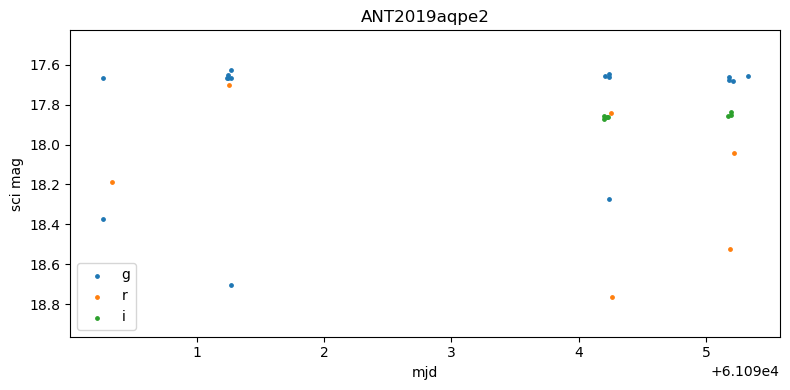

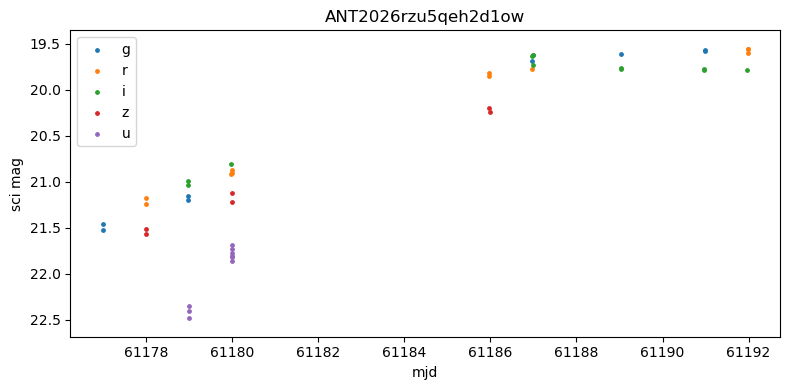

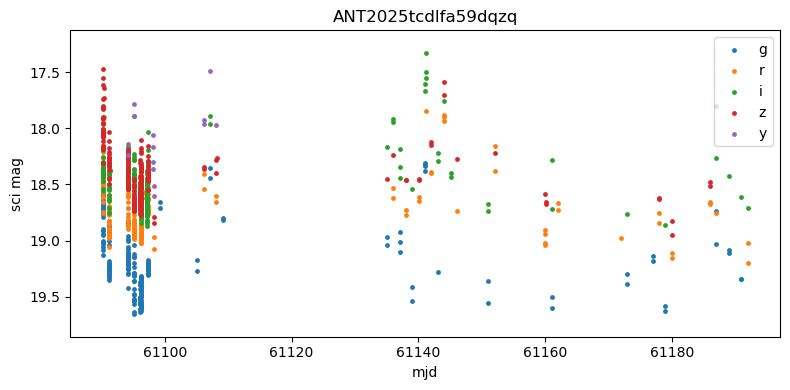

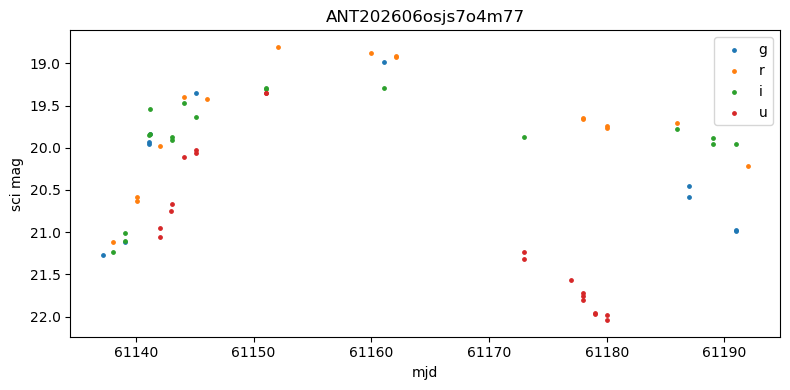

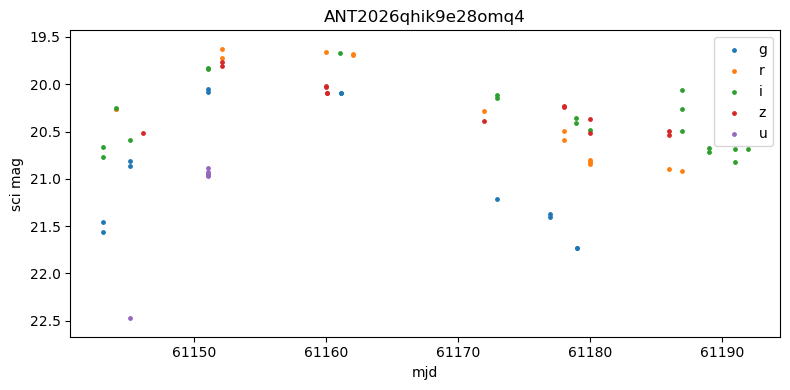

In [340]:
for key in oids_0602q:
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    max_mags = []
    min_mags = []
    for band in oids_0602q[key]:
        if oids_0602q[key][band] == 0:
            continue

        max_mags.append(max(oids_0602q[key][band]['mag']))
        min_mags.append(min(oids_0602q[key][band]['mag']))
            
        plt.scatter(oids_0602q[key][band]['mjd'], oids_0602q[key][band]['mag'], s=6, label=band)

    plt.ylim([max(max_mags)+0.2, min(min_mags)-0.2])
    plt.legend()
    
    plt.title(key)
    plt.ylabel('sci mag')
    plt.xlabel('mjd')
    plt.tight_layout()

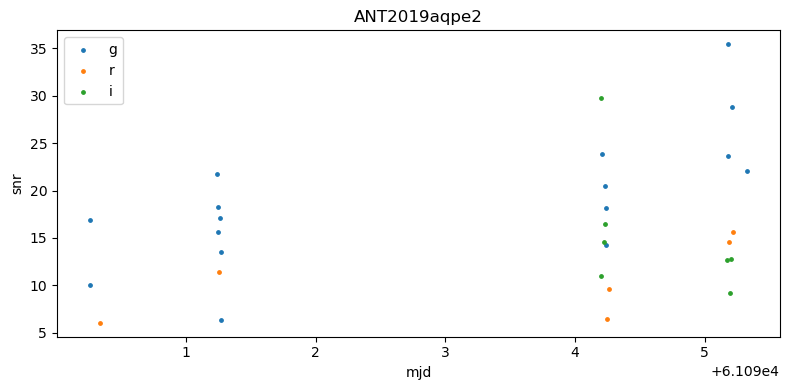

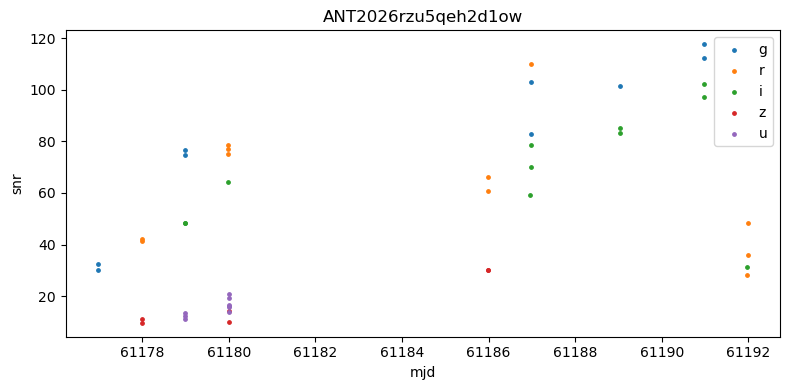

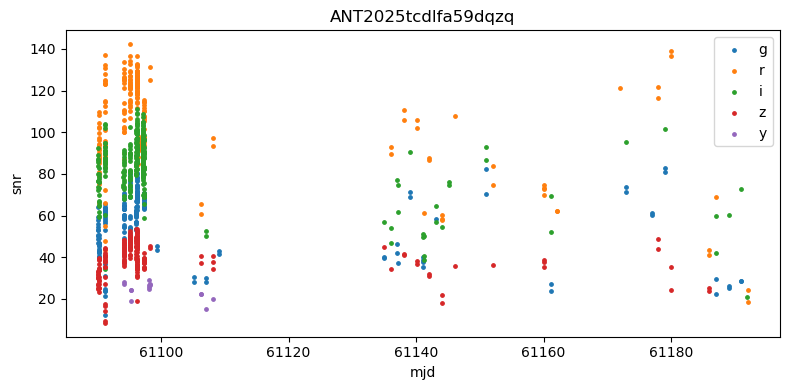

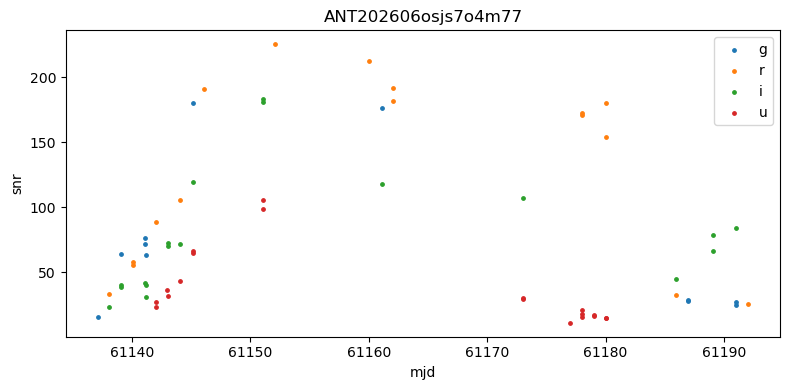

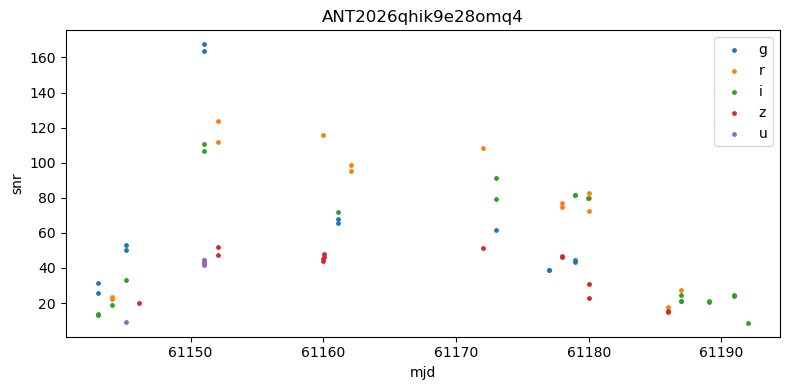

In [382]:
for key in oids_0602q:
    fig, ax = plt.subplots(1,1, figsize=(8,4))
    max_mags = []
    min_mags = []
    for band in oids_0602q[key]:
        if oids_0602q[key][band] == 0:
            continue

        # max_mags.append(max(oids_0602q[key][band]['mag']))
        # min_mags.append(min(oids_0602q[key][band]['mag']))
            
        plt.scatter(oids_0602q[key][band]['mjd'], oids_0602q[key][band]['snr'], s=6, label=band)

    # plt.ylim([max(max_mags)+0.2, min(min_mags)-0.2])
    plt.legend()
    
    plt.title(key)
    plt.ylabel('snr')
    plt.xlabel('mjd')
    plt.tight_layout()

the above code found [ANT2026rzu5qeh2d1ow](https://antares.noirlab.edu/loci/ANT2026rzu5qeh2d1ow), which i think would work great as a base for things to look for. from what i can see of its lightcurve as of now (61192.7 06_02_2026), it is following the TDE pattern. its first 4 detections show a sharp slope upwards, followed by a week w/out observations, and then another week with a small increase at first and then steady brightness afterwards. currently, its first detection is only from 15 days ago, so if my filter would let an object like this pass, then i think it will do well. it is also nice that LSST observed in the ugriz bands (missing y) in those first 4 days and each with at least 3 observations. i think this will be a good object for testing. 

looking at the variance and hyper_v values for just the first 4 days of observations from this object, just using the variance would not be enough to allow this object to pass through the filter. for the u, r, and i filter it would pass through the toughest (so far) of the hyper_v threshold (being over 2), but looking at the ratio from the difference mag and the variance, im not sure if i want to use that since the coefficient of 4 in the equation for hyper_v is dependent on this ratio being around that which it is not even close to for any of these, ranging from ~ 20 - 110, way too far of a range to use to determine this coefficient. ugh

i also looked at the snr from the dif image, but its hard to decipher what is useful and what isnt since its affected by the updating template mag (which fluctuates by either negligable amounts or by ~ 0.5 mag in some cases. is this small enough to still be negligable? how can i include this error in looking at the snr? idk :///

one thing this filter doesnt address is how the science mag changes in all bands across the 4 days, and all change in the same direction (getting brighter) - how do i do this, and include space for error when the difference is like 21.97 followed by 22.03? that difference is likely within error

im going to go thru the 5 oids that did pass thru this filter and see how many days of observations until it passes the filter. my hope is that the 3 that seem to be true transients (low, 77, and q4) will pass thru the filter prior to the peak in their lightcurves, but i dont think that will happen. lets see!

In [281]:
def find_obs_mjds(oid):
    mjd_start = 100000
    mjd_end = 0
    for band in oid:
        if oid[band] == 0:
            continue
        mjd_start_here = oid[band]['mjd'][0]
        if mjd_start_here < mjd_start:
            mjd_start = mjd_start_here
        
        mjd_end_here = oid[band]['mjd'][-1]
        if mjd_end_here > mjd_end:
            mjd_end = mjd_end_here
    return mjd_start, mjd_end

In [386]:
oids_0602q['ANT2019aqpe2']['g']['mjd']

[61090.2581880138,
 61090.26281811891,
 61091.239595921645,
 61091.243611679616,
 61091.24594029818,
 61091.26519795521,
 61091.269144535276,
 61091.27147174363,
 61094.20862138895,
 61094.23475912203,
 61094.23935393257,
 61094.24118896006,
 61095.1795632422,
 61095.18002958969,
 61095.2088428691,
 61095.32848646294]

In [400]:
for key in oids_0602q:
    mjd_start, mjd_end = find_obs_mjds(oids_0602q[key]) #mjd
    nights = round(mjd_end - mjd_start)
    days_to_trigger = []
    for band in oids_0602q[key]:
        if oids_0602q[key][band]==0:
            continue
            
        here_var = 0
        night = 1
        mjd_i = 0 
        mjds_tot = np.array(oids_0602q[key][band]['mjd'])

        while night < nights:
            latest_mjd = round(mjd_start + night)
            i_s = np.where(np.logical_and(mjds_tot < latest_mjd, mjds_tot > latest_mjd-20))
            s_r, s_c = np.shape(i_s)

            if s_c >= 3:
                mags = oids_0602q[key][band]['mag'][i_s[0][0]:s_c]
                here_var = float(np.var(mags))

                if here_var > 0.1:
                    print(f'{key} on {latest_mjd} has variance: {here_var} in {band} band {int(i_s[0][0]),s_c}, triggered in {night} nights\n')
                    break
                else:
                    night += 1
                    
            elif len(i_s) <= 3:
                night += 1

ANT2019aqpe2 on 61092 has variance: 0.15238094372432556 in g band (0, 8), triggered in 2 nights

ANT2026rzu5qeh2d1ow on 61187 has variance: 0.6456176788796277 in g band (0, 6), triggered in 10 nights

ANT2026rzu5qeh2d1ow on 61186 has variance: 0.3050323127814244 in r band (0, 7), triggered in 9 nights

ANT2026rzu5qeh2d1ow on 61187 has variance: 0.41592897726931727 in i band (0, 6), triggered in 10 nights

ANT2026rzu5qeh2d1ow on 61186 has variance: 0.31154240879394585 in z band (0, 6), triggered in 9 nights

ANT202606osjs7o4m77 on 61142 has variance: 0.40119013096573986 in g band (0, 5), triggered in 5 nights

ANT202606osjs7o4m77 on 61143 has variance: 0.16194235488163705 in r band (0, 4), triggered in 6 nights

ANT202606osjs7o4m77 on 61142 has variance: 0.4853912793782665 in i band (0, 6), triggered in 5 nights

ANT202606osjs7o4m77 on 61145 has variance: 0.10824863104256313 in u band (0, 5), triggered in 8 nights

ANT2026qhik9e28omq4 on 61146 has variance: 0.11266866988871951 in g band

In [400]:
def moving_window_var(oid, day_lim, var_lim)
    mjd_start, mjd_end = find_obs_mjds(oid) #mjd
    nights = round(mjd_end - mjd_start)
    days_to_trigger = []
    for band in oids:
        if oid[band]==0:
            continue
            
        here_var = 0
        night = 1
        mjd_i = 0 
        mjds_tot = np.array(oid[band]['mjd'])

        while night < nights:
            latest_mjd = round(mjd_start + night)
            i_s = np.where(np.logical_and(mjds_tot < latest_mjd, mjds_tot > latest_mjd-day_lim))
            s_r, s_c = np.shape(i_s)

            if s_c >= 3:
                mags = oid[band]['mag'][i_s[0][0]:s_c]
                here_var = float(np.var(mags))

                if here_var > var_lim:
                    print(f'{key} on {latest_mjd} has variance: {here_var} in {band} band {int(i_s[0][0]),s_c}, triggered in {night} nights\n')
                    break
                else:
                    night += 1
                    
            elif len(i_s) <= 3:
                night += 1

ANT2019aqpe2 on 61092 has variance: 0.15238094372432556 in g band (0, 8), triggered in 2 nights

ANT2026rzu5qeh2d1ow on 61187 has variance: 0.6456176788796277 in g band (0, 6), triggered in 10 nights

ANT2026rzu5qeh2d1ow on 61186 has variance: 0.3050323127814244 in r band (0, 7), triggered in 9 nights

ANT2026rzu5qeh2d1ow on 61187 has variance: 0.41592897726931727 in i band (0, 6), triggered in 10 nights

ANT2026rzu5qeh2d1ow on 61186 has variance: 0.31154240879394585 in z band (0, 6), triggered in 9 nights

ANT202606osjs7o4m77 on 61142 has variance: 0.40119013096573986 in g band (0, 5), triggered in 5 nights

ANT202606osjs7o4m77 on 61143 has variance: 0.16194235488163705 in r band (0, 4), triggered in 6 nights

ANT202606osjs7o4m77 on 61142 has variance: 0.4853912793782665 in i band (0, 6), triggered in 5 nights

ANT202606osjs7o4m77 on 61145 has variance: 0.10824863104256313 in u band (0, 5), triggered in 8 nights

ANT2026qhik9e28omq4 on 61146 has variance: 0.11266866988871951 in g band

this looks good! all of the ones that I was interested in (ANT2026rzu5qeh2d1ow, ANT202606osjs7o4m77, and ANT2026qhik9e28omq4 due to their lightcurve) were triggered very quickly (less than 9 nights). i am worried that maybe they triggered too quickly, or that they only triggered so quickly because they had no history and that if there Was a history, it wouldve taken longer for them to trigger (from the start of the increase)